<a href="https://colab.research.google.com/github/yawarabbasmalik/PythonBasics/blob/main/Employee_Attrition_and_Factors.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Importing Dataset

In [ ]:
#Importing Necessary Libraries

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder, MinMaxScaler
import numpy as np
from sklearn.model_selection import cross_val_score, cross_val_predict
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier
from sklearn.model_selection import KFold
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import StratifiedKFold
# from imblearn.over_sampling import SMOTE
from sklearn.feature_selection import SelectKBest, mutual_info_classif, chi2, RFE


In [ ]:
#Importing Dataset
hr_data = pd.read_csv("/content/HR_Analytics.csv")
hr_data.head()


,Age,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,...,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager,Attrition
0,41,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,2,...,80,0,8,0,1,6,4,0,5,Yes
1,49,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,3,...,80,1,10,3,3,10,7,1,7,No
2,37,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,4,...,80,0,7,3,3,0,0,0,0,Yes
3,33,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,4,...,80,0,8,3,3,8,7,3,0,No
4,27,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,1,...,80,1,6,3,3,2,2,2,2,No


## Checking Null Values Count in the Entire Dataframe

In [ ]:
hr_data.isna().sum()

Age                         0
BusinessTravel              0
DailyRate                   0
Department                  0
DistanceFromHome            0
Education                   0
EducationField              0
EmployeeCount               0
EmployeeNumber              0
EnvironmentSatisfaction     0
Gender                      0
HourlyRate                  0
JobInvolvement              0
JobLevel                    0
JobRole                     0
JobSatisfaction             0
MaritalStatus               0
MonthlyIncome               0
MonthlyRate                 0
NumCompaniesWorked          0
Over18                      0
OverTime                    0
PercentSalaryHike           0
PerformanceRating           0
RelationshipSatisfaction    0
StandardHours               0
StockOptionLevel            0
TotalWorkingYears           0
TrainingTimesLastYear       0
WorkLifeBalance             0
YearsAtCompany              0
YearsInCurrentRole          0
YearsSinceLastPromotion     0
YearsWithC

From the above outcome, we can see that there exists no null value in the whole dataset.

## Checking Duplicate Values Count in the Entire Dataframe

In [ ]:
hr_data.duplicated().sum()

0

From the above outcome, we can see that there exists no duplicate value in the whole dataset.

## Checking the Shape (Rows, Columns) of Entire Dataframe

In [ ]:
# Get DataFrame shape
shape = hr_data.shape
print('DataFrame Shape :', shape)
print('Number of rows :', shape[0])
print('Number of columns :', shape[1])

DataFrame Shape : (1470, 35)
Number of rows : 1470
Number of columns : 35


## Getting the Summary of Entire Dataframe

In [ ]:
hr_data.describe(include='all')

,Age,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,...,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager,Attrition
count,1470.000000,1470,1470.000000,1470,1470.000000,1470.000000,1470,1470.0,1470.000000,1470.000000,...,1470.0,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470
unique,NaN,3,NaN,3,NaN,NaN,6,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2
top,NaN,Travel_Rarely,NaN,Research & Development,NaN,NaN,Life Sciences,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,No
freq,NaN,1043,NaN,961,NaN,NaN,606,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1233
mean,36.923810,NaN,802.485714,NaN,9.192517,2.912925,NaN,1.0,1024.865306,2.721769,...,80.0,0.793878,11.279592,2.799320,2.761224,7.008163,4.229252,2.187755,4.123129,NaN
std,9.135373,NaN,403.509100,NaN,8.106864,1.024165,NaN,0.0,602.024335,1.093082,...,0.0,0.852077,7.780782,1.289271,0.706476,6.126525,3.623137,3.222430,3.568136,NaN
min,18.000000,NaN,102.000000,NaN,1.000000,1.000000,NaN,1.0,1.000000,1.000000,...,80.0,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,NaN
25%,30.000000,NaN,465.000000,NaN,2.000000,2.000000,NaN,1.0,491.250000,2.000000,...,80.0,0.000000,6.000000,2.000000,2.000000,3.000000,2.000000,0.000000,2.000000,NaN
50%,36.000000,NaN,802.000000,NaN,7.000000,3.000000,NaN,1.0,1020.500000,3.000000,...,80.0,1.000000,10.000000,3.000000,3.000000,5.000000,3.000000,1.000000,3.000000,NaN
75%,43.000000,NaN,1157.000000,NaN,14.000000,4.000000,NaN,1.0,1555.750000,4.000000,...,80.0,1.000000,15.000000,3.000000,3.000000,9.000000,7.000000,3.000000,7.000000,NaN


## Confirming the DataType of Each Variable in the Entire Dataframe

In [ ]:
hr_data.dtypes

Age                          int64
BusinessTravel              object
DailyRate                    int64
Department                  object
DistanceFromHome             int64
Education                    int64
EducationField              object
EmployeeCount                int64
EmployeeNumber               int64
EnvironmentSatisfaction      int64
Gender                      object
HourlyRate                   int64
JobInvolvement               int64
JobLevel                     int64
JobRole                     object
JobSatisfaction              int64
MaritalStatus               object
MonthlyIncome                int64
MonthlyRate                  int64
NumCompaniesWorked           int64
Over18                      object
OverTime                    object
PercentSalaryHike            int64
PerformanceRating            int64
RelationshipSatisfaction     int64
StandardHours                int64
StockOptionLevel             int64
TotalWorkingYears            int64
TrainingTimesLastYea

Showing the data type of each attribute, we can see that few attributes are integers (numeric) where few are Object (categorical/nominal) attributes.

# Exploratory Data Analysis (EDA)

Now, We'll create five different visualizations to explore the factors that might be related to attrition:

**Attrition Rate by Age Group:** To see if certain age groups are more prone to attrition.

**Attrition Rate by Department:** To understand if attrition is more prevalent in certain departments.

**Years at Company vs. Attrition:** To explore the relationship between the tenure at the company and attrition.

**Job Satisfaction vs. Attrition:** Analyzing if job satisfaction levels have a significant impact on attrition.

**Attrition Distribution by Education Field:** To investigate whether the field of education influences attrition rates.

<Figure size 1000x600 with 0 Axes>

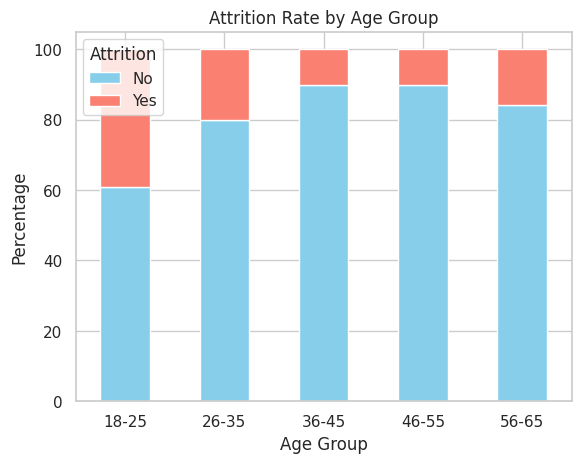

Attrition,No,Yes
AgeGroup,,
18-25,60.824742,39.175258
26-35,79.783394,20.216606
36-45,89.900990,10.099010
46-55,89.795918,10.204082
56-65,84.057971,15.942029


In [ ]:
# Setting the aesthetic style of the plots
sns.set(style="whitegrid")

# 1. Attrition Rate by Age Group
# Creating age groups
bins = [18, 25, 35, 45, 55, 65]
labels = ['18-25', '26-35', '36-45', '46-55', '56-65']
hr_data['AgeGroup'] = pd.cut(hr_data['Age'], bins=bins, labels=labels, right=False)

# Calculating attrition rate for each age group
age_group_attrition = hr_data.groupby('AgeGroup')['Attrition'].value_counts(normalize=True).unstack()
age_group_attrition = age_group_attrition.multiply(100)

# Plotting
plt.figure(figsize=(10, 6))
age_group_attrition.plot(kind='bar', stacked=True, color=['skyblue', 'salmon'])
plt.title('Attrition Rate by Age Group')
plt.xlabel('Age Group')
plt.ylabel('Percentage')
plt.legend(title='Attrition', labels=['No', 'Yes'])
plt.xticks(rotation=0)
plt.show()

age_group_attrition


The first visualization presents the attrition rate across different age groups: 18-25, 26-35, 36-45, 46-55, and 56-65. It is evident from the stacked bar chart that younger employees (especially those between 18-25 years) have a significantly higher attrition rate compared to other age groups. Approximately 39% of employees in this age bracket have left the company, which is nearly double or more than that of the older age groups. The attrition rate decreases as the age increases, with the lowest rates observed in the 36-55 age brackets. This trend might indicate that younger employees are either exploring more career options or are less satisfied with their current roles compared to their older counterparts.

Now, let's move on to the second visualization: Attrition Rate by Department.

<Figure size 1000x600 with 0 Axes>

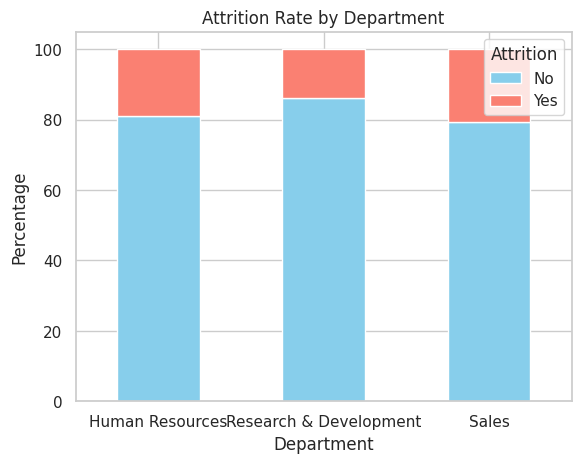

Attrition,No,Yes
Department,,
Human Resources,80.952381,19.047619
Research & Development,86.160250,13.839750
Sales,79.372197,20.627803


In [ ]:
# 2. Attrition Rate by Department
department_attrition = hr_data.groupby('Department')['Attrition'].value_counts(normalize=True).unstack()
department_attrition = department_attrition.multiply(100)

# Plotting
plt.figure(figsize=(10, 6))
department_attrition.plot(kind='bar', stacked=True, color=['skyblue', 'salmon'])
plt.title('Attrition Rate by Department')
plt.xlabel('Department')
plt.ylabel('Percentage')
plt.legend(title='Attrition', labels=['No', 'Yes'])
plt.xticks(rotation=0)
plt.show()

department_attrition


The second visualization displays the attrition rate across different departments: Human Resources, Research & Development, and Sales. From the bar chart, it's observable that the Sales and Human Resources departments have a higher attrition rate compared to Research & Development. Specifically, Sales and Human Resources departments show attrition rates of approximately 21% and 19% respectively, whereas Research & Development has a lower rate at around 14%. This difference could be indicative of varying job satisfaction levels, work pressures, or career advancement opportunities across these departments.

No we will generate the third visualization, which focuses on the relationship between the number of years an employee has been with the company and their likelihood of leaving (attrition).

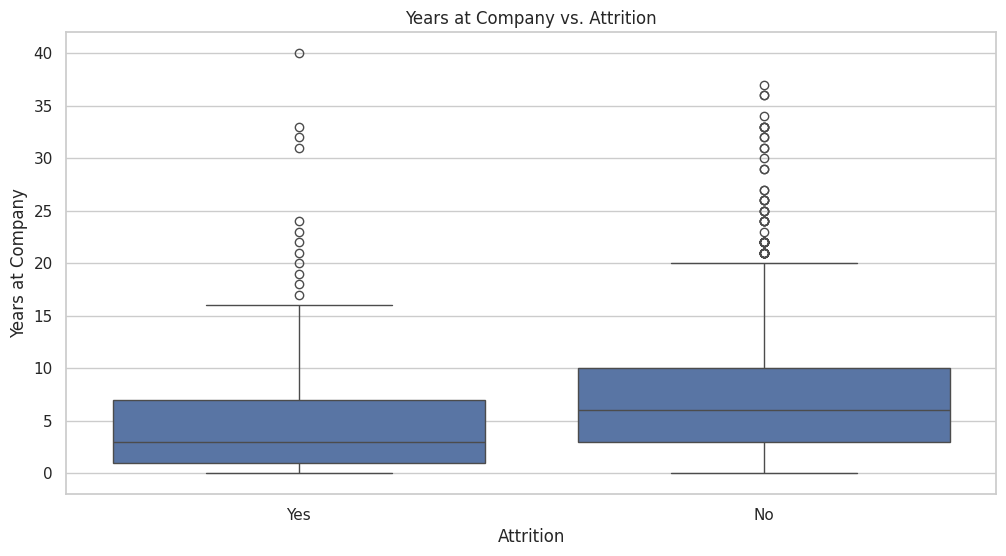

In [ ]:
# 3. Years at Company vs. Attrition
plt.figure(figsize=(12, 6))
sns.boxplot(x="Attrition", y="YearsAtCompany", data=hr_data)
plt.title('Years at Company vs. Attrition')
plt.xlabel('Attrition')
plt.ylabel('Years at Company')
plt.show()


The third visualization is a boxplot showing the distribution of the number of years employees have spent at the company, differentiated by their attrition status. The plot reveals that employees who have left the company (Yes for attrition) generally have fewer years at the company compared to those who haven't left (No for attrition). The median tenure for those who left is notably lower, suggesting that attrition is more common among employees with shorter service durations. This could imply that longer tenure might be associated with greater job satisfaction, better integration into the company culture, or more investment in the company, leading to lower attrition rates.

Let's proceed to the fourth visualization, which will explore the impact of job satisfaction on attrition

<Figure size 1000x600 with 0 Axes>

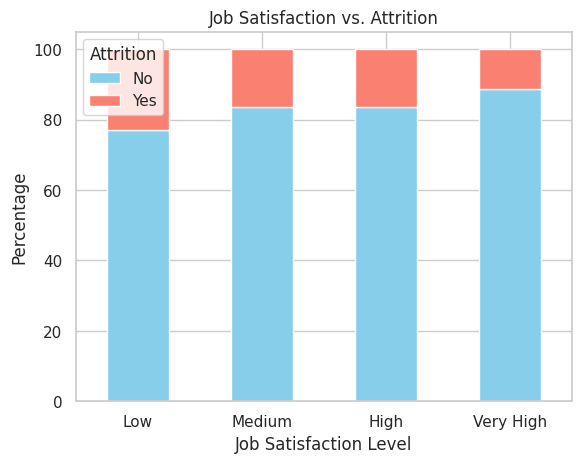

Attrition,No,Yes
JobSatisfaction,,
1,77.162630,22.837370
2,83.571429,16.428571
3,83.484163,16.515837
4,88.671024,11.328976


In [ ]:
# 4. Job Satisfaction vs. Attrition
job_satisfaction_attrition = hr_data.groupby('JobSatisfaction')['Attrition'].value_counts(normalize=True).unstack()
job_satisfaction_attrition = job_satisfaction_attrition.multiply(100)

# Plotting
plt.figure(figsize=(10, 6))
job_satisfaction_attrition.plot(kind='bar', stacked=True, color=['skyblue', 'salmon'])
plt.title('Job Satisfaction vs. Attrition')
plt.xlabel('Job Satisfaction Level')
plt.ylabel('Percentage')
plt.legend(title='Attrition', labels=['No', 'Yes'])
plt.xticks([0, 1, 2, 3], ['Low', 'Medium', 'High', 'Very High'], rotation=0)
plt.show()

job_satisfaction_attrition


This bar chart illustrates the relationship between job satisfaction levels (ranging from low to very high) and attrition rates. It is evident that employees with the lowest job satisfaction (level 1) have the highest attrition rate, at about 23%. As the job satisfaction level increases, the attrition rate decreases correspondingly. Employees with the highest level of job satisfaction (level 4) have the lowest attrition rate, around 11%. This trend underscores the importance of job satisfaction in employee retention, suggesting that higher job satisfaction is associated with lower attrition rates.



Finally, We will create the fifth visualization, focusing on the distribution of attrition across different education fields. ​​



<Figure size 1200x600 with 0 Axes>

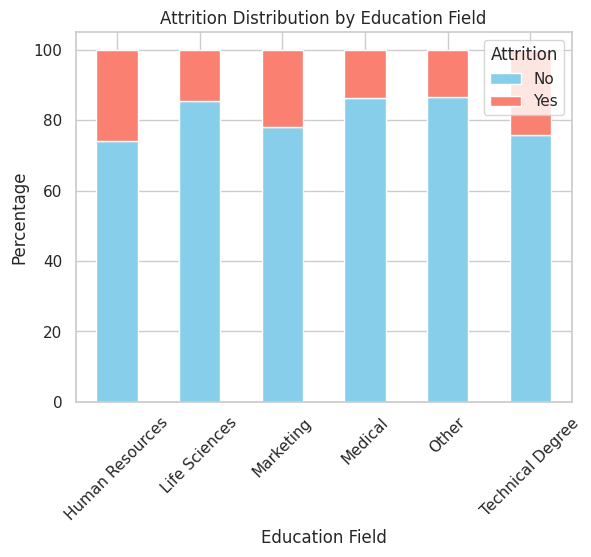

Attrition,No,Yes
EducationField,,
Human Resources,74.074074,25.925926
Life Sciences,85.313531,14.686469
Marketing,77.987421,22.012579
Medical,86.422414,13.577586
Other,86.585366,13.414634
Technical Degree,75.757576,24.242424


In [ ]:
# 5. Attrition Distribution by Education Field
education_field_attrition = hr_data.groupby('EducationField')['Attrition'].value_counts(normalize=True).unstack()
education_field_attrition = education_field_attrition.multiply(100)

# Plotting
plt.figure(figsize=(12, 6))
education_field_attrition.plot(kind='bar', stacked=True, color=['skyblue', 'salmon'])
plt.title('Attrition Distribution by Education Field')
plt.xlabel('Education Field')
plt.ylabel('Percentage')
plt.legend(title='Attrition', labels=['No', 'Yes'])
plt.xticks(rotation=45)
plt.show()

education_field_attrition


The final visualization shows the attrition rates across different education fields, including Human Resources, Life Sciences, Marketing, Medical, Other, and Technical Degree. From the bar chart, it is clear that the fields of Human Resources and Technical Degree have the highest attrition rates, around 26% and 24% respectively. On the other hand, fields like Medical, Other, and Life Sciences exhibit lower attrition rates, around 14%. The variation in attrition rates across different educational backgrounds might indicate the role of job relevance, satisfaction, and opportunities within the field in influencing an employee's decision to stay with or leave the company.



## Feature Engineering

In [ ]:
# Convert categorical columns to string or another suitable type before calculations
categorical_columns = hr_data.select_dtypes(include=['category']).columns
hr_data[categorical_columns] = hr_data[categorical_columns].astype(str)

# Calculating the new variables
hr_data['JSI'] = hr_data['YearsAtCompany'] / hr_data['TotalWorkingYears']
hr_data['DER'] = hr_data['DailyRate'] / hr_data['DistanceFromHome']
hr_data['WLBS'] = hr_data['WorkLifeBalance'] * hr_data['JobSatisfaction']
hr_data['RHR'] = hr_data['DailyRate'] / hr_data['StandardHours']
hr_data['PWT'] = hr_data['YearsSinceLastPromotion'] / hr_data['YearsAtCompany']

# Handling potential infinities and NaNs resulting from the division
hr_data['JSI'].replace([float('inf'), float('-inf')], 0, inplace=True)
hr_data['DER'].replace([float('inf'), float('-inf')], 0, inplace=True)
hr_data['WLBS'].replace([float('inf'), float('-inf')], 0, inplace=True)
hr_data['RHR'].replace([float('inf'), float('-inf')], 0, inplace=True)
hr_data['PWT'].replace([float('inf'), float('-inf')], 0, inplace=True)

hr_data.fillna(0, inplace=True)

# Optionally, convert the columns back to categorical if needed
hr_data[categorical_columns] = hr_data[categorical_columns].astype('category')


In [ ]:
# Removing the 'AgeGroup' column from the hr_data DataFrame
hr_data = hr_data.drop('AgeGroup', axis=1)
hr_data.head()

,Age,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,...,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager,Attrition,JSI,DER,WLBS,RHR,PWT
0,41,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,2,...,6,4,0,5,Yes,0.750000,1102.000,4,13.7750,0.000
1,49,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,3,...,10,7,1,7,No,1.000000,34.875,6,3.4875,0.100
2,37,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,4,...,0,0,0,0,Yes,0.000000,686.500,9,17.1625,0.000
3,33,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,4,...,8,7,3,0,No,1.000000,464.000,9,17.4000,0.375
4,27,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,1,...,2,2,2,2,No,0.333333,295.500,6,7.3875,1.000


The new variables have been successfully added to the dataset. Here's a brief description of each:

**JSI (Job Stability Index):** This index provides a measure of an employee's stability or tenure at the current company relative to their total working years. A lower JSI could indicate a propensity for higher attrition.

**DER (Distance Efficiency Ratio):** This ratio measures the efficiency of compensation in relation to the commuting distance. A lower DER might suggest that the commuting burden is not adequately offset by the daily rate, possibly leading to higher attrition.

**WLBS (Work-Life Balance Score):** This score is a product of work-life balance and job satisfaction levels. It aims to capture the overall contentment of an employee with their work and personal life balance, with lower scores potentially indicating higher attrition risk.

**RHR (Relative Hourly Rate):** This variable gives insight into how the daily rate compares to standard working hours, providing a perspective on how the employee's time is valued.

**PWT (Promotion Wait Time):** This ratio indicates the waiting time for a promotion relative to the tenure at the company. Higher values might be associated with perceived stagnation or lack of progression, potentially leading to increased attrition.

These new variables could potentially enhance the predictive modeling of attrition rates by providing additional dimensions to employee profiles.

## Data Transformation & Data Normalization

In [ ]:
# Creating a copy of the dataframe for encoding and normalization
df_encoded = hr_data.copy()

# Initializing Label Encoder
le = LabelEncoder()

# Applying Label Encoding to categorical columns
categorical_columns = df_encoded.select_dtypes(include=['object']).columns
for column in categorical_columns:
    df_encoded[column] = le.fit_transform(df_encoded[column])

# Applying Min-Max Normalization
scaler = MinMaxScaler()
df_normalized = pd.DataFrame(scaler.fit_transform(df_encoded), columns=df_encoded.columns)

# Displaying the first few rows of the normalized dataframe
df_normalized.head()


,Age,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,...,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager,Attrition,JSI,DER,WLBS,RHR,PWT
0,0.547619,1.0,0.715820,1.0,0.000000,0.25,0.2,0.0,0.000000,0.333333,...,0.15,0.222222,0.000000,0.294118,1.0,0.750000,0.735873,0.200000,0.715820,0.000
1,0.738095,0.5,0.126700,0.5,0.250000,0.00,0.2,0.0,0.000484,0.666667,...,0.25,0.388889,0.066667,0.411765,0.0,1.000000,0.020502,0.333333,0.126700,0.100
2,0.452381,1.0,0.909807,0.5,0.035714,0.25,0.8,0.0,0.001451,1.000000,...,0.00,0.000000,0.000000,0.000000,1.0,0.000000,0.457334,0.533333,0.909807,0.000
3,0.357143,0.5,0.923407,0.5,0.071429,0.75,0.2,0.0,0.001935,1.000000,...,0.20,0.388889,0.200000,0.000000,0.0,1.000000,0.308176,0.533333,0.923407,0.375
4,0.214286,1.0,0.350036,0.5,0.035714,0.00,0.6,0.0,0.002903,0.000000,...,0.05,0.111111,0.133333,0.117647,0.0,0.333333,0.195218,0.333333,0.350036,1.000


The above outcome shows that, data encoding is carried out, where all the categorical and nominal attributes are converted to numeric values so that it became easy for the computer systems to understand the data.

Min-Max normalization is carried out to make the data in uniform pattern i.e. whole the data is now in between 0-1.

## Data Splitting for ML Modeling

In [ ]:
# Splitting the normalized dataframe into independent (X) and dependent (y) variables
X = df_normalized.drop('Attrition', axis=1)  # Independent variables
y = df_normalized['Attrition']               # Dependent variable (target class)

Preparing the data for Predictive modeling where target class and indepedent class attributes in the dataset are separated.

# Employee Attrition Predictive Analysis

In [ ]:
# Define the models
models = {
    "Logistic Regression": LogisticRegression(),
    "Naive Bayes": GaussianNB(),
    "KNN": KNeighborsClassifier(),
    "Decision Tree": DecisionTreeClassifier(),
    "Random Forest": RandomForestClassifier(),
    "SVM": SVC(probability=True),
    "XGBoost": XGBClassifier(use_label_encoder=False, eval_metric='logloss')
}

# 10-fold Cross-validation
kf = KFold(n_splits=10, random_state=42, shuffle=True)

# Evaluation
for name, model in models.items():
    y_pred = cross_val_predict(model, X, y, cv=kf, method="predict_proba")
    y_pred_label = np.argmax(y_pred, axis=1)
    accuracy = accuracy_score(y, y_pred_label)
    precision = precision_score(y, y_pred_label)
    recall = recall_score(y, y_pred_label)
    f1 = f1_score(y, y_pred_label)
    auc = roc_auc_score(y, y_pred[:, 1])
    cm = confusion_matrix(y, y_pred_label)
    print(f"{name}: Accuracy={accuracy}, Precision={precision}, Recall={recall}, F1-Score={f1}, AUC={auc}, Confusion Matrix=\n{cm}")


Logistic Regression: Accuracy=0.8625850340136054, Precision=0.6699029126213593, Recall=0.2911392405063291, F1-Score=0.40588235294117647, AUC=0.8096406486871237, Confusion Matrix=
[[1199   34]
 [ 168   69]]
Naive Bayes: Accuracy=0.7721088435374149, Precision=0.3717277486910995, Recall=0.5991561181434599, F1-Score=0.4588045234248788, AUC=0.7653385622525417, Confusion Matrix=
[[993 240]
 [ 95 142]]
KNN: Accuracy=0.8496598639455782, Precision=0.625, Recall=0.16877637130801687, F1-Score=0.26578073089701, AUC=0.6834211093658566, Confusion Matrix=
[[1209   24]
 [ 197   40]]
Decision Tree: Accuracy=0.7768707482993197, Precision=0.32432432432432434, Recall=0.35443037974683544, F1-Score=0.3387096774193548, AUC=0.6062500641637666, Confusion Matrix=
[[1058  175]
 [ 153   84]]
Random Forest: Accuracy=0.8591836734693877, Precision=0.7777777777777778, Recall=0.17721518987341772, F1-Score=0.28865979381443296, AUC=0.8018896656982216, Confusion Matrix=
[[1221   12]
 [ 195   42]]
SVM: Accuracy=0.86190476

7 different Predictive ML models are applied using 10-fold cross validation (where whole the data is splitted into 10 different chunks and eveytime one chunk is used for testing while all other 9 chunks for training and this exercise keep on repeating till all the chunks are tested).

Purpose of using 7 different models is comparison. To find out which model is more efficient for predicting the employee attrition rate. Hence, we confirmed that XG Boost model is the best, based on accuracy rate and confusion matrix.

## Ensemble Modeling

In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.ensemble import StackingClassifier

# Define the base models
base_models = [
    ('xgboost', XGBClassifier(use_label_encoder=False, eval_metric='logloss')),
    ('logistic_regression', LogisticRegression())
]

# Define the meta-model
meta_model = LogisticRegression()

# Create the stacking classifier with the preprocessor
stacking_model = Pipeline(steps=[
    # ('preprocessor', preprocessor),
    ('classifier', StackingClassifier(estimators=base_models, final_estimator=meta_model, cv=10))
])

# 10-fold Cross-validation
kf = KFold(n_splits=10, random_state=42, shuffle=True)

# Evaluate the stacking model using cross-validation
y_pred = cross_val_predict(stacking_model, X, y, cv=kf, method="predict_proba")
y_pred_label = np.argmax(y_pred, axis=1)

# Evaluate the model
accuracy = accuracy_score(y, y_pred_label)
precision = precision_score(y, y_pred_label)
recall = recall_score(y, y_pred_label)
f1 = f1_score(y, y_pred_label)
auc = roc_auc_score(y, y_pred[:, 1])
cm = confusion_matrix(y, y_pred_label)

print(f"Stacking Model: Accuracy={accuracy*100:.2f}%, Precision={precision*100:.2f}%, Recall={recall*100:.2f}%, F1-Score={f1*100:.2f}%, AUC={auc*100:.2f}%")
print(f"Confusion Matrix:\n{cm}")

Stacking Model: Accuracy=87.41%, Precision=75.49%, Recall=32.49%, F1-Score=45.43%, AUC=81.82%
Confusion Matrix:
[[1208   25]
 [ 160   77]]


## Sampling Technique

In [ ]:
!pip install --upgrade scikit-learn
!pip install --upgrade imbalanced-learn


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 258.3/258.3 kB 1.8 MB/s eta 0:00:00
  Attempting uninstall: imbalanced-learn
    Found existing installation: imbalanced-learn 0.10.1
    Uninstalling imbalanced-learn-0.10.1:
      Successfully uninstalled imbalanced-learn-0.10.1


In [ ]:
from imblearn.over_sampling import SMOTE

# Create a features DataFrame excluding the target variable
X_features = df_normalized.drop('Attrition', axis=1)  # Replace 'Attrition' with your actual target column name

# Define your models
models = {
    "Logistic Regression": LogisticRegression(),
    "Naive Bayes": GaussianNB(),
    "KNN": KNeighborsClassifier(),
    "Decision Tree": DecisionTreeClassifier(),
    "Random Forest": RandomForestClassifier(),
    "SVM": SVC(probability=True),
    "XGBoost": XGBClassifier(use_label_encoder=False, eval_metric='logloss')
}

# Prepare StratifiedKFold for cross-validation
kf = StratifiedKFold(n_splits=10)

# Loop through each model to perform cross-validation
for name, model in models.items():
    accuracy, precision, recall, f1, auc = [], [], [], [], []
    cm_sum = np.zeros((2, 2))  # Adjust for binary/multiclass

    for train_index, test_index in kf.split(X_features, y):
        X_train, X_test = X_features.iloc[train_index], X_features.iloc[test_index]
        y_train, y_test = y.iloc[train_index], y.iloc[test_index]

        # Apply SMOTE
        smote = SMOTE()
        X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

        # Fit the model and make predictions
        model.fit(X_train_smote, y_train_smote)
        y_pred_label = model.predict(X_test)
        y_pred = model.predict_proba(X_test)[:, 1] if hasattr(model, "predict_proba") else model.decision_function(X_test)

        # Calculate metrics and update the sums
        accuracy.append(accuracy_score(y_test, y_pred_label))
        precision.append(precision_score(y_test, y_pred_label))
        recall.append(recall_score(y_test, y_pred_label))
        f1.append(f1_score(y_test, y_pred_label))
        auc.append(roc_auc_score(y_test, y_pred))
        cm_sum += confusion_matrix(y_test, y_pred_label)

    # Calculate average of the metrics
    avg_accuracy = np.mean(accuracy)
    avg_precision = np.mean(precision)
    avg_recall = np.mean(recall)
    avg_f1 = np.mean(f1)
    avg_auc = np.mean(auc)

    # Print the results
    print(f"{name}: Accuracy={avg_accuracy:.4f}, Precision={avg_precision:.4f}, Recall={avg_recall:.4f}, F1-Score={avg_f1:.4f}, AUC={avg_auc:.4f}, Confusion Matrix=\n{cm_sum}")


ImportError: cannot import name '_check_X' from 'imblearn.utils._validation' (/usr/local/lib/python3.10/dist-packages/imblearn/utils/_validation.py)

## Category-Wise Analysis

In [ ]:
# Define your feature categories
categories = {
    "Demographic Factors": ["Age", "Gender", "MaritalStatus", "Education", "EducationField"],  # Update with actual columns
    "Job Characteristics": ["BusinessTravel", "Department", "JobRole", "JobLevel"],  # Update with actual columns
    "Work Environment": ["DistanceFromHome", "EnvironmentSatisfaction"],  # Update with actual columns
    "Employee Satisfaction": ["JobInvolvement", "JobSatisfaction"],  # Update with actual columns
    "Career Development": ["YearsAtCompany", "YearsInCurrentRole"],  # Update with actual columns
    "Derived Metrics": ["JSI", "DER", "WLBS", "RHR", "PWT"]  # Update with actual columns
}

# Prepare StratifiedKFold for cross-validation
kf = StratifiedKFold(n_splits=10)

# Define the XGBoost model
xgb_model = XGBClassifier(use_label_encoder=False, eval_metric='logloss')

# Loop through each category to perform cross-validation
for category, features in categories.items():
    accuracy, precision, recall, f1, auc = [], [], [], [], []
    cm_sum = np.zeros((2, 2))  # Assuming binary classification for confusion matrix

    for train_index, test_index in kf.split(df_normalized[features], y):
        X_train, X_test = df_normalized[features].iloc[train_index], df_normalized[features].iloc[test_index]
        y_train, y_test = y.iloc[train_index], y.iloc[test_index]

        # Fit the model and make predictions
        xgb_model.fit(X_train, y_train)
        y_pred_label = xgb_model.predict(X_test)
        y_pred = xgb_model.predict_proba(X_test)

        # Calculate metrics and update the sums
        accuracy.append(accuracy_score(y_test, y_pred_label))
        precision.append(precision_score(y_test, y_pred_label))
        recall.append(recall_score(y_test, y_pred_label))
        f1.append(f1_score(y_test, y_pred_label))
        auc.append(roc_auc_score(y_test, y_pred[:, 1]))
        cm_sum += confusion_matrix(y_test, y_pred_label)

    # Calculate average of the metrics
    avg_accuracy = np.mean(accuracy)
    avg_precision = np.mean(precision)
    avg_recall = np.mean(recall)
    avg_f1 = np.mean(f1)
    avg_auc = np.mean(auc)

    # Print the results
    print(f"{category}: Accuracy={avg_accuracy:.4f}, Precision={avg_precision:.4f}, Recall={avg_recall:.4f}, F1-Score={avg_f1:.4f}, AUC={avg_auc:.4f}, Confusion Matrix=\n{cm_sum}")


Demographic Factors: Accuracy=0.8041, Precision=0.2980, Recall=0.1393, F1-Score=0.1860, AUC=0.5917, Confusion Matrix=
[[1149.   84.]
 [ 204.   33.]]


/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


Job Characteristics: Accuracy=0.8408, Precision=0.5012, Recall=0.0723, F1-Score=0.1248, AUC=0.7086, Confusion Matrix=
[[1219.   14.]
 [ 220.   17.]]


/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


Work Environment: Accuracy=0.8286, Precision=0.2050, Recall=0.0382, F1-Score=0.0633, AUC=0.4963, Confusion Matrix=
[[1209.   24.]
 [ 228.    9.]]


/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision is ill-defin

Employee Satisfaction: Accuracy=0.8367, Precision=0.0000, Recall=0.0000, F1-Score=0.0000, AUC=0.5976, Confusion Matrix=
[[1230.    3.]
 [ 237.    0.]]


/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision is ill-defin

Career Development: Accuracy=0.8333, Precision=0.0000, Recall=0.0000, F1-Score=0.0000, AUC=0.6217, Confusion Matrix=
[[1225.    8.]
 [ 237.    0.]]
Derived Metrics: Accuracy=0.8014, Precision=0.2312, Recall=0.0978, F1-Score=0.1335, AUC=0.5714, Confusion Matrix=
[[1155.   78.]
 [ 214.   23.]]


## Feature Subset Selection

In [ ]:
# We need to create a features DataFrame excluding the target variable
X_features = df_normalized.drop('Attrition', axis=1)  # Replace 'Attrition' with your actual target column name

# Correlation
correlation = X_features.apply(lambda x: x.corr(y))
top_10_corr_features = correlation.abs().sort_values(ascending=False).head(10).index.tolist()

# Information Gain
info_gain_selector = SelectKBest(mutual_info_classif, k=10)
info_gain_selector.fit(X_features, y)
top_10_info_gain_features = X_features.columns[info_gain_selector.get_support()].tolist()

# Chi-Squared
chi2_selector = SelectKBest(chi2, k=10)
chi2_selector.fit(X_features, y)
top_10_chi2_features = X_features.columns[chi2_selector.get_support()].tolist()

# Recursive Feature Elimination
rfe_selector = RFE(estimator=DecisionTreeClassifier(), n_features_to_select=10)
rfe_selector.fit(X_features, y)
top_10_rfe_features = X_features.columns[rfe_selector.get_support()].tolist()

# Prepare your feature subsets
feature_subsets = {
    "Top 10 Correlation": X_features[top_10_corr_features],
    "Top 10 Information Gain": X_features[top_10_info_gain_features],
    "Top 10 Chi-Squared": X_features[top_10_chi2_features],
    "Top 10 RFE": X_features[top_10_rfe_features]
}

# Define the XGBoost model
xgb_model = XGBClassifier(use_label_encoder=False, eval_metric='logloss')

# StratifiedKFold for cross-validation
kf = StratifiedKFold(n_splits=10)

# Loop through each feature subset
for subset_name, X in feature_subsets.items():
    accuracy, precision, recall, f1, auc = [], [], [], [], []
    cm_sum = np.zeros((2, 2))  # Adjust for binary/multiclass

    for train_index, test_index in kf.split(X, y):
        X_train, X_test = X.iloc[train_index], X.iloc[test_index]
        y_train, y_test = y.iloc[train_index], y.iloc[test_index]

        # Fit the model
        xgb_model.fit(X_train, y_train)
        y_pred = xgb_model.predict(X_test)
        y_pred_proba = xgb_model.predict_proba(X_test)[:, 1]  # Adjust index for binary/multiclass

        # Metrics
        accuracy.append(accuracy_score(y_test, y_pred))
        precision.append(precision_score(y_test, y_pred))
        recall.append(recall_score(y_test, y_pred))
        f1.append(f1_score(y_test, y_pred))
        auc.append(roc_auc_score(y_test, y_pred_proba))
        cm_sum += confusion_matrix(y_test, y_pred)

    # Print metrics
    print(f"{subset_name} - Accuracy: {np.mean(accuracy):.4f}, Precision: {np.mean(precision):.4f}, Recall: {np.mean(recall):.4f}, F1-Score: {np.mean(f1):.4f}, AUC: {np.mean(auc):.4f}\nConfusion Matrix:\n{cm_sum}\n")


Top 10 Correlation - Accuracy: 0.8361, Precision: 0.4891, Recall: 0.3078, F1-Score: 0.3687, AUC: 0.7379
Confusion Matrix:
[[1156.   77.]
 [ 164.   73.]]

Top 10 Information Gain - Accuracy: 0.8177, Precision: 0.3814, Recall: 0.2248, F1-Score: 0.2787, AUC: 0.6950
Confusion Matrix:
[[1149.   84.]
 [ 184.   53.]]

Top 10 Chi-Squared - Accuracy: 0.8367, Precision: 0.4895, Recall: 0.3163, F1-Score: 0.3773, AUC: 0.7610
Confusion Matrix:
[[1155.   78.]
 [ 162.   75.]]

Top 10 RFE - Accuracy: 0.8313, Precision: 0.4852, Recall: 0.2272, F1-Score: 0.2920, AUC: 0.6961
Confusion Matrix:
[[1168.   65.]
 [ 183.   54.]]



# Variable Importance

In [ ]:
# Create a features DataFrame excluding the target variable
X_features = df_normalized.drop('Attrition', axis=1)  # Replace 'Attrition' with the actual target column name

# Train the XGBoost model
model = XGBClassifier(use_label_encoder=False, eval_metric='logloss')
model.fit(X_features, y)

# Get feature importances
importances = model.feature_importances_

# Convert the importances into a DataFrame
feature_importances = pd.DataFrame({
    'Feature': X_features.columns,
    'Importance': importances
})

# Sort the DataFrame by importance
sorted_feature_importances = feature_importances.sort_values('Importance', ascending=False)

# Display the sorted feature importances
print(sorted_feature_importances)


                     Feature  Importance
21                  OverTime    0.084719
26          StockOptionLevel    0.058081
27         TotalWorkingYears    0.044693
17             MonthlyIncome    0.041114
12            JobInvolvement    0.039636
16             MaritalStatus    0.039141
3                 Department    0.038853
31        YearsInCurrentRole    0.036439
36                      WLBS    0.035693
0                        Age    0.035045
30            YearsAtCompany    0.030582
19        NumCompaniesWorked    0.030048
4           DistanceFromHome    0.029597
14                   JobRole    0.029194
32   YearsSinceLastPromotion    0.029032
24  RelationshipSatisfaction    0.028655
9    EnvironmentSatisfaction    0.027112
13                  JobLevel    0.026598
38                       PWT    0.024641
6             EducationField    0.024592
33      YearsWithCurrManager    0.024067
1             BusinessTravel    0.023379
29           WorkLifeBalance    0.022248
35              

<ipython-input-36-39c4804a05c5>:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="Importance", y="Feature", data=df, palette="viridis")


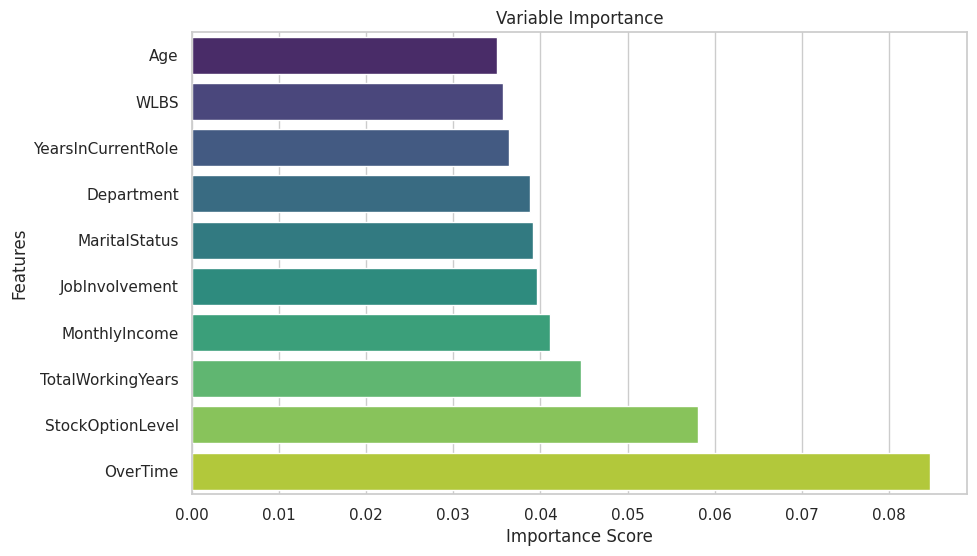

In [ ]:
# Given data
feature_data = {
    'Feature': ['OverTime', 'StockOptionLevel', 'TotalWorkingYears', 'MonthlyIncome', 'JobInvolvement',
                'MaritalStatus', 'Department', 'YearsInCurrentRole', 'WLBS', 'Age'],
    'Importance': [0.084719, 0.058081, 0.044693, 0.041114, 0.039636,
                   0.039141, 0.038853, 0.036439, 0.035693, 0.035045]
}

# Create a DataFrame
df = pd.DataFrame(feature_data)

# Sort the DataFrame by importance for better visualization
df = df.sort_values('Importance', ascending=True)

# Set the aesthetic style of the plots
sns.set(style="whitegrid")

# Plotting
plt.figure(figsize=(10, 6))
sns.barplot(x="Importance", y="Feature", data=df, palette="viridis")
plt.title('Variable Importance')
plt.xlabel('Importance Score')
plt.ylabel('Features')
plt.show()


From the above figure results, we can evaluate that "Monthly Income", "Age", "DailyRate", "EmployeeNumber" & "OverTime" are the top 5 attributes that are possible way of employees' attrition.